[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mlnjsh/Introduction-to-Deep-Learning/blob/main/notebooks_DeepLearning/02_optimizers_pytorch.ipynb)

# 02. Comparing Optimizers — PyTorch

Same architecture, different `torch.optim` optimizers: **SGD, SGD+Momentum, RMSprop, Adam, Adagrad**. Each run starts from the same seed.

**Dataset:** `loan_prediction_data.csv` — 614 loan applications, 11 pre-normalised features, binary target `Loan_Status` (1 = approved).

> This is the PyTorch twin of `02_..._keras.ipynb`. Where Keras hides the training loop inside `model.fit`, here we **write the loop explicitly** — that is the main thing to compare.

---

## 1. Setup & imports

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch", torch.__version__, "| device:", device)

PyTorch 2.11.0+cpu | device: cpu


## 2. Load the data

In [2]:
import os, numpy as np, pandas as pd
from sklearn.model_selection import train_test_split

# Robust load: works whether the notebook runs from its own folder or the parent
CSV = "loan_prediction_data.csv"
if not os.path.exists(CSV):
    CSV = os.path.join("..", "loan_prediction_data.csv")

df = pd.read_csv(CSV)
print("Shape:", df.shape)
df.head()

Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,0.0,0.0,0.000000,1.0,0.0,0.070489,0.000000,0.198860,0.74359,1.0,1.0,1.0
1,LP001003,0.0,1.0,0.333333,1.0,0.0,0.054830,0.036192,0.172214,0.74359,1.0,0.0,0.0
2,LP001005,0.0,1.0,0.000000,1.0,1.0,0.035250,0.000000,0.082489,0.74359,1.0,1.0,1.0
3,LP001006,0.0,1.0,0.000000,0.0,0.0,0.030093,0.056592,0.160637,0.74359,1.0,1.0,1.0
4,LP001008,0.0,0.0,0.000000,1.0,0.0,0.072356,0.000000,0.191027,0.74359,1.0,1.0,1.0


## 3. Prepare features & train/test split

Features are already scaled to `[0,1]`; we drop the ID and do a **stratified** split.

In [3]:
# Features are ALREADY normalised to [0,1] in this dataset, so no scaling needed.
# Drop the ID column and separate the target.
X = df.drop(columns=["Loan_ID", "Loan_Status"]).values.astype("float32")
y = df["Loan_Status"].values.astype("float32")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
N_FEATURES = X_train.shape[1]
print("Train:", X_train.shape, " Test:", X_test.shape, " Features:", N_FEATURES)
print("Train positive rate: %.3f  Test positive rate: %.3f" % (y_train.mean(), y_test.mean()))

Train: (491, 11)  Test: (123, 11)  Features: 11
Train positive rate: 0.686  Test positive rate: 0.691


In [4]:
# Wrap the numpy arrays as float tensors. Target is shaped (N,1) to match the
# sigmoid output and BCELoss.
Xtr = torch.tensor(X_train)
ytr = torch.tensor(y_train).view(-1, 1)
Xte = torch.tensor(X_test)
yte = torch.tensor(y_test).view(-1, 1)
print("Xtr", tuple(Xtr.shape), "| ytr", tuple(ytr.shape))

Xtr (491, 11) | ytr (491, 1)


In [5]:
def train_model(model, optimizer, epochs=100, batch_size=32, clip=None, loss_fn=None):
    """Train `model`, returning a Keras-style history dict so we can reuse plot_history."""
    if loss_fn is None:
        loss_fn = nn.BCELoss()
    loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=batch_size, shuffle=True)
    hist = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            if clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), clip)   # gradient clipping
            optimizer.step()
        # end-of-epoch metrics on the full train & test sets
        model.eval()
        with torch.no_grad():
            tr, te = model(Xtr), model(Xte)
            hist["loss"].append(loss_fn(tr, ytr).item())
            hist["val_loss"].append(loss_fn(te, yte).item())
            hist["accuracy"].append((((tr > 0.5) == (ytr > 0.5)).float().mean()).item())
            hist["val_accuracy"].append((((te > 0.5) == (yte > 0.5)).float().mean()).item())
    return hist

In [6]:
def plot_history(hist, title=""):
    """Plot train (solid) vs test (dashed) loss and accuracy over epochs."""
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(hist["loss"], label="train")
    ax[0].plot(hist["val_loss"], "--", label="test")
    ax[0].set_title(title + " — Loss"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss")
    ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(hist["accuracy"], label="train")
    ax[1].plot(hist["val_accuracy"], "--", label="test")
    ax[1].set_title(title + " — Accuracy"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy")
    ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()

## 4. One model, many optimizers

In [7]:
def fresh_model():
    torch.manual_seed(42)                 # identical starting weights each time
    return nn.Sequential(
        nn.Linear(N_FEATURES, 16), nn.ReLU(),
        nn.Linear(16, 1), nn.Sigmoid(),
    )

def make_opt(name, params):
    params = list(params)      # materialise: the dict below builds every optimizer,
                               # and a generator would be drained by the first one.
    return {
        "SGD":          torch.optim.SGD(params, lr=0.01),
        "SGD+Momentum": torch.optim.SGD(params, lr=0.01, momentum=0.9),
        "RMSprop":      torch.optim.RMSprop(params, lr=0.01),
        "Adam":         torch.optim.Adam(params, lr=0.01),
        "Adagrad":      torch.optim.Adagrad(params, lr=0.01),
    }[name]

names = ["SGD", "SGD+Momentum", "RMSprop", "Adam", "Adagrad"]
results = {}
for name in names:
    m = fresh_model()
    results[name] = train_model(m, make_opt(name, m.parameters()), epochs=100)
    print("%-14s final test acc = %.3f | test loss = %.3f" %
          (name, results[name]["val_accuracy"][-1], results[name]["val_loss"][-1]))

SGD            final test acc = 0.732 | test loss = 0.522


SGD+Momentum   final test acc = 0.862 | test loss = 0.398


RMSprop        final test acc = 0.829 | test loss = 0.424


Adam           final test acc = 0.854 | test loss = 0.402


Adagrad        final test acc = 0.854 | test loss = 0.416


## 5. Comparison table

In [8]:
summary = pd.DataFrame({
    name: {
        "final_train_acc": h["accuracy"][-1],
        "final_test_acc":  h["val_accuracy"][-1],
        "final_test_loss": h["val_loss"][-1],
        "best_test_acc":   max(h["val_accuracy"]),
    } for name, h in results.items()
}).T.sort_values("best_test_acc", ascending=False)
summary.round(4)

,final_train_acc,final_test_acc,final_test_loss,best_test_acc
SGD+Momentum,0.7984,0.8618,0.3981,0.8618
Adam,0.8310,0.8537,0.4025,0.8618
RMSprop,0.7984,0.8293,0.4237,0.8618
Adagrad,0.7984,0.8537,0.4156,0.8537
SGD,0.7271,0.7317,0.5225,0.7317


## 6. Overlaid learning curves

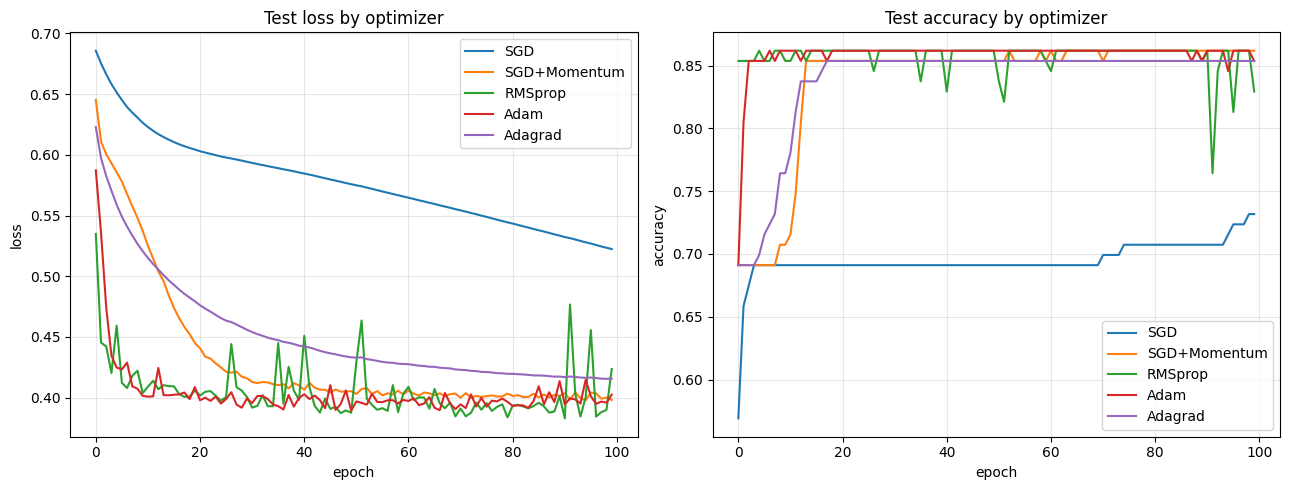

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for name, h in results.items():
    ax[0].plot(h["val_loss"], label=name)
    ax[1].plot(h["val_accuracy"], label=name)
ax[0].set_title("Test loss by optimizer"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss")
ax[1].set_title("Test accuracy by optimizer"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy")
for a in ax: a.legend(); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

## Takeaways
- The `torch.optim` API mirrors Keras: you pass `model.parameters()` and a learning rate.
- **SGD** is slowest; **Momentum** accelerates it; **Adam/RMSprop** adapt per-parameter rates and usually converge fastest here.
- Because both frameworks use the same math, the *ranking* of optimizers is consistent with the Keras notebook — a good sanity check.
- **Next:** `03_weight_init_pytorch`.